# Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

# Task 0 Theoretical proof: (0.5 points)


Task 0 proof that Bellman optimality equation has a unique solutions and iterative policy evaluation can converge to it.

For prooving this we can use a Banach fixed point theorem and using the fact that Bellman operator is a contraction.
### Banach Fixed-Point Theorem (Contraction Mapping Theorem)


Let $(X, d)$ be a **non-empty complete metric space**.

A mapping $T: X \to X$ is called a **contraction** (or contraction mapping or operator) if there exists a constant $q \in [0, 1)$ such that for all $x, y \in X$:
$$
d(T(x), T(y)) \le q \cdot d(x, y)
$$

The constant $q$ is known as the **Lipschitz constant** or the **contraction factor**.
## Banach fixed point theorem
If $T: X \to X$ is a contraction on a non-empty complete metric space $(X, d)$, then:

 **Existence and Uniqueness:** $T$ has exactly one fixed point $x^* \in X$. That is, there exists a unique $x^*$ such that:
    $$
    T(x^*) = x^*
    $$

**Convergence:** For any initial point $x_0 \in X$, the sequence defined by the iteration:
    $$
    x_{n+1} = T(x_n), \quad n = 0, 1, 2, \dots
    $$
    converges to $x^*$.




The only thing that is left to proove is that Bellman optimality operator B is contraction mapping:


$B^{\pi}(v^{∗}) = max_{\pi}(r_{\pi}+\gamma P_{\pi}v^{*})$ 
Proove this here: 

#TODO:

You should prove that 
$$
\|B^{\pi}(V_1) - B^{\pi}(V_2)\|_\infty \leq \alpha \|(V_1) - (V_2)\|_\infty 
$$
 $0<\alpha<1$

Where **max norm** also known as the **infinity norm**, **supremum norm**

For a vector $x = [x_1, x_2, \dots, x_n] \in \mathbb{R}^n$, the max norm is defined as the maximum absolute value among its components:

$$
\|x\|_\infty = \max_{i \in \{1, \dots, n\}} |x_i|
$$


## Your proof here(you can a photo of your written  notes ot use markdown)

![img](./data/task0_value_based.jpg)

# Task 1: Write a code of MDP based on this schema and description: (1 point)
Imagine you are Cobb.  Every time you go deeper into a dream, things get more unstable. If you mess up, you end up in Limbo.
## The Setup of the MDP
### States: You start on the Plane (S0). You can dive into Level 1 (S1), Level 2 (S2), or Level 3 (S3).
### Goal: Reach Success (S4) by planting the idea.
Main Danger: If you fail, you hit Failure (S5) and the game is  over.

### The Actions: 
1) Go Deeper 
2) ​Stabilize 

3) Abort/Kick Up 
​


![Pasted Graphic.png](<attachment:Pasted Graphic.png>)
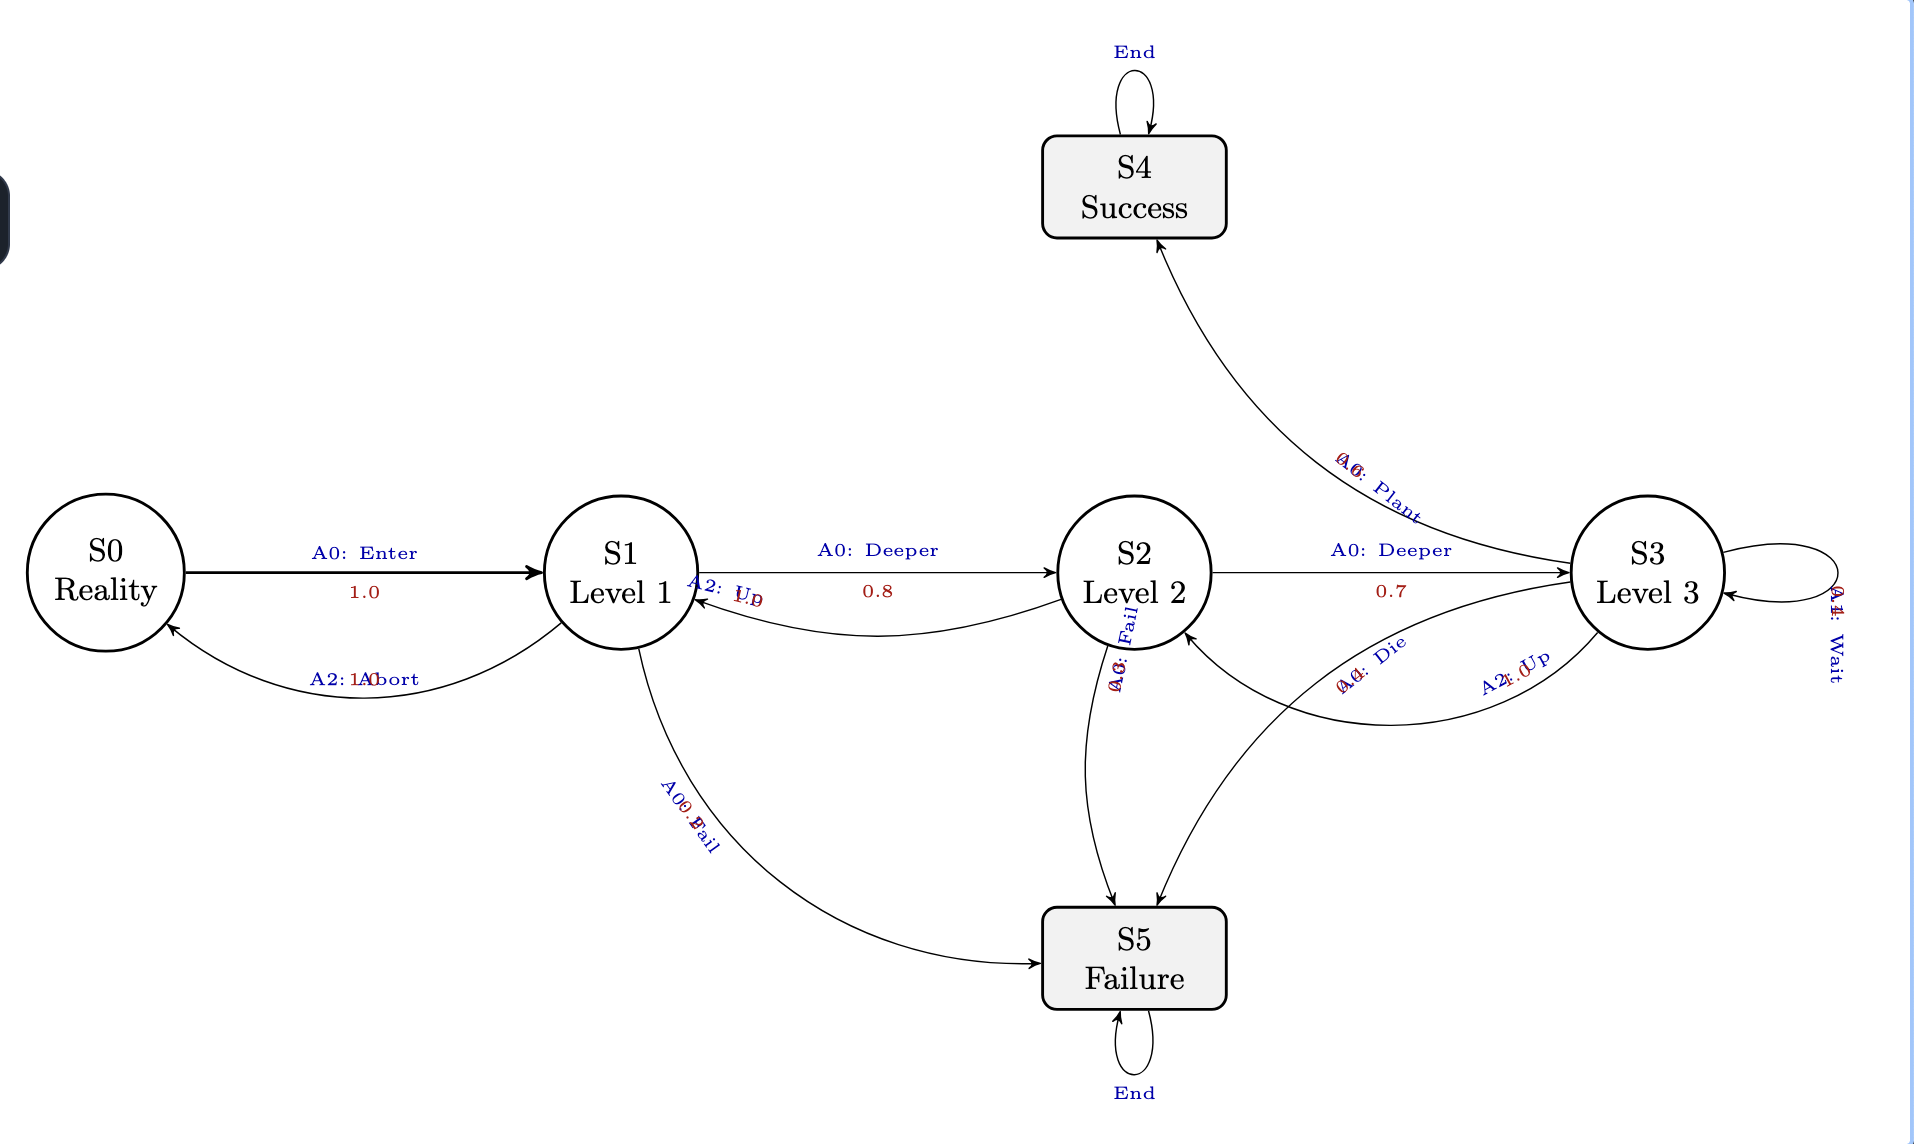

In [ ]:
import numpy as np
from enum import IntEnum
from dataclasses import dataclass
from typing import List, Tuple


class STATE(IntEnum):

    REALITY = 0
    LEVEL_1 = 1
    LEVEL_2 = 2
    LEVEL_3 = 3
    SUCCESS = 4
    FAILURE = 5

class ACTION(IntEnum):
    GO_DEEPER = 0
    STABILIZE = 1
    ABORT = 2


@dataclass
class Transition:

    probability: float
    next_state: STATE
    reward: float

class InceptionMDP:


    def __init__(self):
        self.n_states = len(STATE)
        self.n_actions = len(ACTION)

        # store dynamics: dynamics[state][action] = List[Transition]
        self.dynamics = {
            s: {a: [] for a in ACTION} for s in STATE
        }

        self._setup_movie_logic()

    def _add_rule(self, state: STATE, action: ACTION, prob: float, next_state: STATE, reward: float):
        """Helper to add a transition rule cleanly."""
        self.dynamics[state][action].append(Transition(prob, next_state, reward))

    def _setup_movie_logic(self):
        """
        Defines the probabilities and rewards based on the movie plot.
        """


        self._add_rule(STATE.REALITY, ACTION.GO_DEEPER, 1.0, STATE.LEVEL_1, 0)

        self._add_rule(STATE.REALITY, ACTION.STABILIZE, 1.0, STATE.REALITY, -1)
        self._add_rule(STATE.REALITY, ACTION.ABORT,    1.0, STATE.REALITY, -1)


        self._add_rule(STATE.LEVEL_1, ACTION.GO_DEEPER, 0.8, STATE.LEVEL_2, 0)
        self._add_rule(STATE.LEVEL_1, ACTION.GO_DEEPER, 0.2, STATE.FAILURE, -10)

        self._add_rule(STATE.LEVEL_1, ACTION.STABILIZE, 0.9, STATE.LEVEL_1, -1)
        self._add_rule(STATE.LEVEL_1, ACTION.STABILIZE, 0.1, STATE.FAILURE, -10)


        self._add_rule(STATE.LEVEL_1, ACTION.ABORT, 1.0, STATE.REALITY, -2)


        self._add_rule(STATE.LEVEL_2, ACTION.GO_DEEPER, 0.7, STATE.LEVEL_3, 0)
        self._add_rule(STATE.LEVEL_2, ACTION.GO_DEEPER, 0.3, STATE.FAILURE, -10)

        # Stabilize:
        self._add_rule(STATE.LEVEL_2, ACTION.STABILIZE, 0.85, STATE.LEVEL_2, -1)
        self._add_rule(STATE.LEVEL_2, ACTION.STABILIZE, 0.15, STATE.LEVEL_1, -1)

        # Abort: Kick up to Level 1.
        self._add_rule(STATE.LEVEL_2, ACTION.ABORT, 1.0, STATE.LEVEL_1, -2)


        # add transtion from state level 3
        #TODO: <> YOUR CODE here:

        #TERMINAL STATES
        for term_state in [STATE.SUCCESS, STATE.FAILURE]:
            for act in ACTION:
                self._add_rule(term_state, act, 1.0, term_state, 0)

    def get_possible_outcomes(self, state: STATE, action: ACTION) -> List[Transition]:
        return self.dynamics[state][action]

    def step(self, state: STATE, action: ACTION) -> Tuple[STATE, float, bool]:

        if state in [STATE.SUCCESS, STATE.FAILURE]:
            return state, 0.0, True

        outcomes = self.get_possible_outcomes(state, action)

        # Extract probabilities and choices for numpy random choice
        probs = [t.probability for t in outcomes]
        choices = [(t.next_state, t.reward) for t in outcomes]

        # Pick one outcome based on probability distribution
        #TODO: <> YOUR CODE here:
        is_terminal = next_state in [STATE.SUCCESS, STATE.FAILURE]

        return next_state, reward, is_terminal

## Initializing environment

In [ ]:
env = InceptionMDP()


In [ ]:
import numpy as np
class PolicyAgent:
      def __init__(self, n_states=len(STATE), n_actions = len(ACTION)):
        self.n_states = n_states
        self.n_actions = n_actions
      def get_action(self, state):
            if state == STATE.REALITY:
                  action = ACTION.GO_DEEPER
            else:
                  action = np.random.choice([ACTION.GO_DEEPER, ACTION.STABILIZE, ACTION.ABORT])
            return action


In [ ]:
agent = PolicyAgent()

In [ ]:
def play_inception_game(env, agent):
    current_state = STATE.REALITY
    total_reward = 0
    step_count = 0

    # Simple heuristic agent: Always try to go deeper unless in Reality
    while current_state not in [STATE.SUCCESS, STATE.FAILURE] and step_count < 10:
        action = agent.get_action(current_state)
        next_state, reward, done = env.step(current_state, action)

        print(f"Step {step_count+1}: From {current_state.name} : [{action.name}] to  {next_state.name} with Reward: {reward}")

        current_state = next_state
        total_reward += reward
        step_count += 1
    print(f"Ended in {current_state.name}. Total Reward: {total_reward}")


### Play the game 

In [ ]:
play_inception_game(env, agent)

In [ ]:
# Propose another policy better the example policy
import numpy as np
class PolicyAgent:
      def __init__(self, n_states=len(STATE), n_actions = len(ACTION)):
        self.n_states = n_states
        self.n_actions = n_actions
      def get_action(self, state):
          pass
         #TODO: <> YOUR CODE here:


# Task 2 
Let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

# Here use mdp.py attached in github

In [1]:
!pip install gdown

  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.7-cp312-cp312-macosx_10_13_universal2.whl (311 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached PySocks-1.7.1-py3-none-any.whl (16 kB)
Using cached

In [3]:
!gdown https://drive.google.com/uc?id=1gyhaOg7TeRU1Hiq0vLR6ib98oDRaT1mo

zsh:1: no matches found: https://drive.google.com/uc?id=1gyhaOg7TeRU1Hiq0vLR6ib98oDRaT1mo


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from time import sleep
from mdp import MDP, has_graphviz, FrozenLakeEnv
from IPython.display import display, clear_output

%matplotlib inline

In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

We can now use MDP just as any other gym environment:

In [3]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [4]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ",
      mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. For ubuntu just run:

1. `sudo apt-get install graphviz`
2. `pip install graphviz`
3. restart the notebook

For windows this might work: `conda install -c conda-forge python-graphviz`. However, you can ignore this part alltogether and use the standard vizualization.

In [5]:
print("Graphviz available:", has_graphviz)

Graphviz available: True


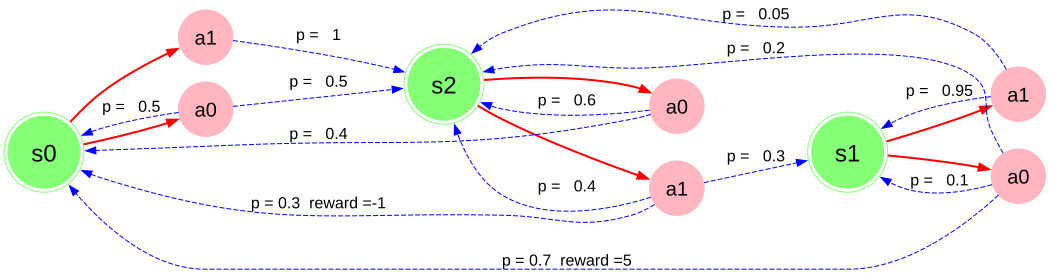

In [6]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, \
        plot_graph_optimal_strategy_and_state_values

    display(plot_graph(mdp))

# Task 3: Value Iteration (up to 1 point)

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max\limits_a \sum\limits_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^*$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [17]:
%%writefile mdp_get_action_value.py
def get_action_value(mdp, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """

    q = 0
    for next_state, ps in mdp.get_next_states(state, action).items():
        r = mdp.get_reward(state, action, next_state)
        q += ps * (r + gamma * state_values[next_state])
        
    return q


Writing mdp_get_action_value.py


In [18]:
from mdp_get_action_value import get_action_value

test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [19]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0

    best_q = None
    for a in mdp.get_possible_actions(state):
        q = get_action_value(mdp, state_values, state, a, gamma)
        best_q = max(best_q, q) if best_q else q


    return best_q

In [20]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert test_Vs == test_Vs_copy, "please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

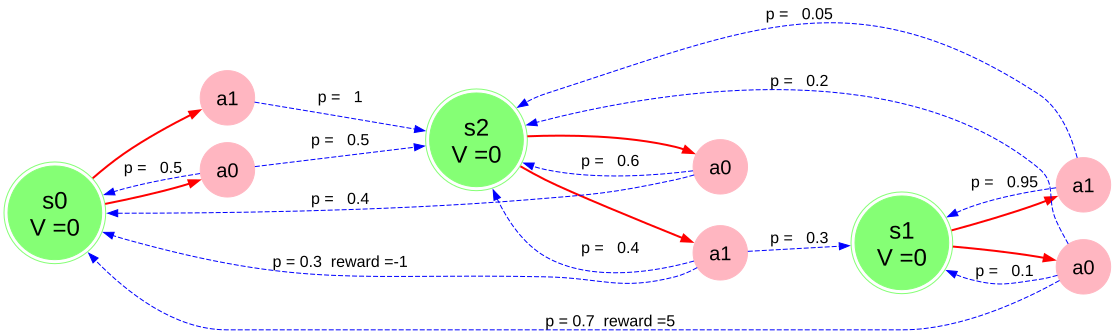

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.83700   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = -0.300
iter    2   |   diff: 0.61830   |   V(s0) = -0.135   V(s1) = 3.761   V(s2) = 0.537
iter    3   |   diff: 0.45791   |   V(s0) = 0.483   V(s1) = 3.850   V(s2) = 0.872
iter    4   |   diff: 0.31734   |   V(s0) = 0.785   V(s1) = 4.308   V(s2) = 1.184
iter    5   |   diff: 0.28561   |   V(s0) = 1.066   V(s1) = 4.595   V(s2) = 1.501
iter    6   |   diff: 0.25148   |   V(s0) = 1.351   V(s1) = 4.855   V(s2) = 1.769
iter    7   |   diff: 0.22062   |   V(s0) = 1.592   V(s1) = 5.107   V(s2) = 2.013
iter    8   |   diff: 0.19855   |   V(s0) = 1.811   V(s1) = 5.325   V(s2) = 2.233
iter    9   |   diff: 0.17842   |   V(s0) = 2.010   V(s1) = 5.522   V(s2) = 2.431
iter   10   |   diff: 0.16026   |   V(s0) = 2.188   V(s1) = 5.701   V(s2) = 2.609
iter   11   |   diff: 0.14424   |   V(s0) = 2.348   V(s1) = 5.861   V(s2) = 2.769
iter   12   | 

In [21]:
# parameters
gamma = 0.9  # discount for MDP
num_iter = 100  # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {
        state: get_new_state_value(mdp, state_values, state, gamma)
        for state in state_values
    }

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print("   ".join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

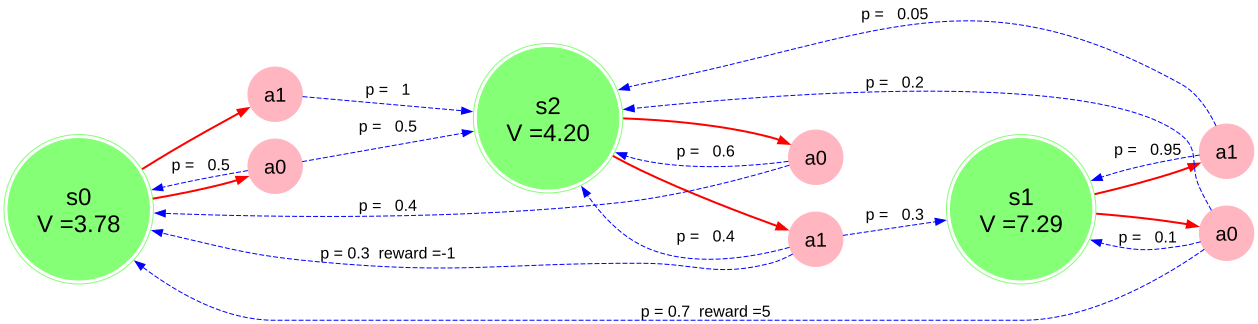

In [22]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [23]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7816909249269743, 's1': 7.294662475246563, 's2': 4.202796326606383}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = \underset{a}{\operatorname{argmax}} \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \underset{a}{\operatorname{argmax}} Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [24]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """Finds optimal action using formula above."""
    if mdp.is_terminal(state):
        return None

    best_action = None
    best_q = None

    for a in mdp.get_possible_actions(state):
        q = get_action_value(mdp, state_values, state, a, gamma)

        if best_q is None or q > best_q:
            best_q = q
            best_action = a

    return best_action

In [25]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

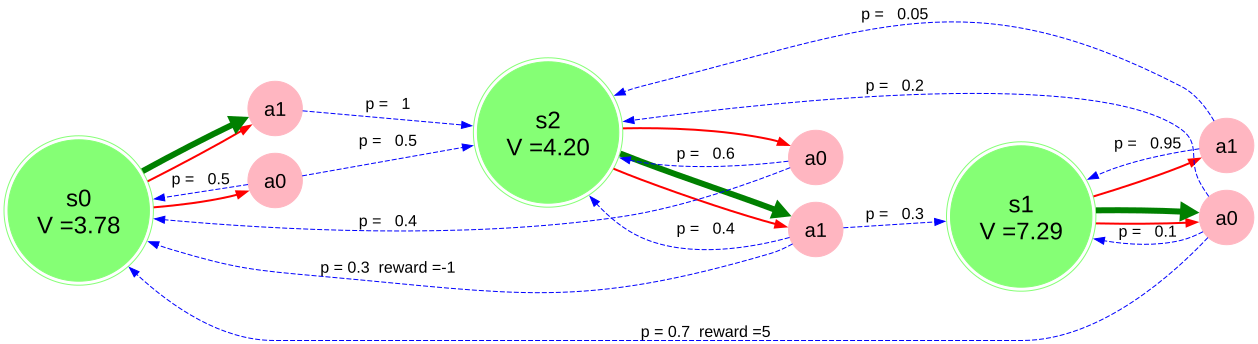

In [26]:
if has_graphviz:
    try:
        display(plot_graph_optimal_strategy_and_state_values(mdp, state_values))
    except ImportError:
        raise ImportError("Run the cell that starts with \"%%writefile mdp_get_action_value.py\"")

In [27]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4741


### Frozen lake

In [28]:
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [29]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = <YOUR CODE HERE >

        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

SyntaxError: invalid syntax (537443924.py, line 7)

In [ ]:
state_values = value_iteration(mdp)

In [ ]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [ ]:


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (-1, 0)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

In [ ]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

In [ ]:
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [ ]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

In [ ]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

In [ ]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

In [ ]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

# Task 4 Policy Iteration (up to 1 points)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \underset{a}{\operatorname*{argmax}} Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [ ]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve` or fixed-point iteration method.)

In [ ]:
def compute_vpi(mdp, policy, gamma):
    """
    Computes V^pi(s) FOR ALL STATES under given policy.
    :param policy: a dict of currently chosen actions {s : a}
    :returns: a dict {state : V^pi(state) for all states}
    """
    # YOUR CODE HERE
    return < YOUR CODE >

In [ ]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

Once we've got new state values, it's time to update our policy.

In [ ]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    <YOUR CODE >
    return < YOUR CODE >

In [ ]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

__Main loop__

In [ ]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """
    < A WHOLE LOT OF YOUR CODE >

    return state_values, policy

__Your PI Results__

In [ ]:
< Compare PI and VI on the custom MDP, then on small & large FrozenLake in terms of the number of iterations needed for convergence >
< Also make sure that your PI implementation passes assert tests for total reward>

# Bonus: Find an MDP for which value iteration takes long to converge  (up to 0.5 points)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6 -- i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions -- we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here -- you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

Note: by default `initial state` is selected randomly, you might want to change this.

In [ ]:
transition_probs = {
    < YOUR CODE >
}
rewards = {
    < YOUR CODE >
}

from numpy import random
mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))
# Feel free to change the initial_state

In [ ]:
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("N actions changed = %i \n" % n_changes)
    policy = new_policy

# please ignore iter 0 at each step